<a href="https://colab.research.google.com/github/ana-leticia-cabral/Meus-estudos-de-Python/blob/main/Exerc%C3%ADcios_Numpy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Gere uma matriz 4x4 de números igualmente espaçados entre 5 e 11 e calcule o total de memória utilizado para armazenar este array.

In [ ]:
import numpy as np

array = np.linspace(5, 11, 16)
matriz = array.reshape(4,4)

memoria_utilizada = (matriz.itemsize * matriz.size)

In [ ]:
matriz

array([[ 5. ,  5.4,  5.8,  6.2],
       [ 6.6,  7. ,  7.4,  7.8],
       [ 8.2,  8.6,  9. ,  9.4],
       [ 9.8, 10.2, 10.6, 11. ]])

In [ ]:
memoria_utilizada

128

2. Assumindo que você tenha um array de apenas inteiros, crie uma função que converte-o para o tipo de dado que minimiza seu uso de memória.

In [ ]:
def minimiza_memoria(array: np.ndarray) -> np.ndarray:
  """
  Minimiza o uso de memória de um determinado array de inteiros

  :param array: array a ser minimizado
  :return: array com o tipo ajustado

  """

  array = array.astype(np.min_scalar_type(array.max()))
  return array

In [ ]:
array = np.array([1, 2, 3])
array.dtype

dtype('int64')

In [ ]:
array = minimiza_memoria(array)

In [ ]:
array.dtype

dtype('uint8')

3. Dado um vetor unidimensional de valores converta-o para uma matriz bi-dimensional com base em um valor de passo e um valor de janela, de tal forma que cada linha dessa matriz contenha o número de colunas definido da janela e que nós percorremos, a cada iteração, o número de passo em termos de elemento.


In [ ]:
# array [1,2,3,4,5,6]
# janela: quantos elementos cada linha vai ter
# passo: de quanto em quanto anda

def vetor_para_matriz(array: np.ndarray, janela: int, passo: int) -> np.ndarray:
  resultado = []

  # len(array): quantidade de elementos -> 6
  # (len(array) - janela) + 1 -> O contador começa do 0 e vai até 4 (não inclusivo)
  for i in range(0, (len(array) - janela) + 1, passo):
    janela_atual = array[i:i + janela]
    resultado.append(janela_atual)
  return np.array(resultado)

In [ ]:
array = np.array([1, 2, 3, 4, 5, 6])

matriz = vetor_para_matriz(array, janela=3, passo=1)
matriz

array([[1, 2, 3],
       [2, 3, 4],
       [3, 4, 5],
       [4, 5, 6]])

4. Crie uma função que permita criar uma matriz quadrada com os seguintes formatos.

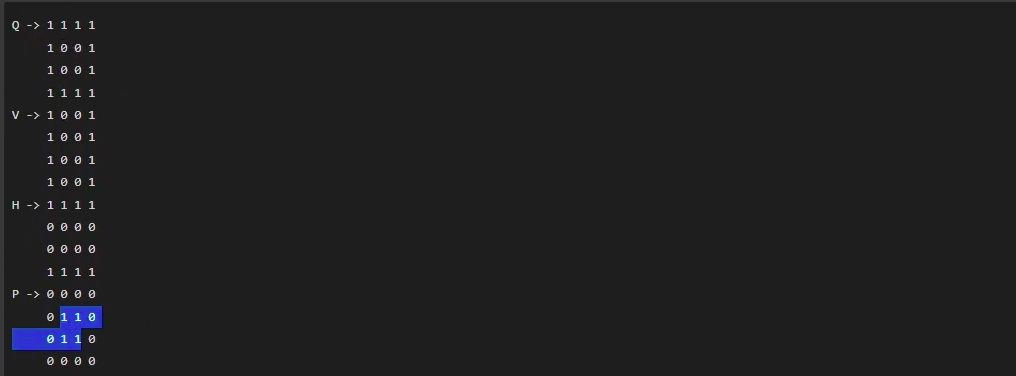

In [ ]:
def mutabilidade () -> None:
  q = np.ones(shape = (4,4))
  v = np.ones(shape = (4,4))
  h = np.ones(shape = (4,4))
  p = np.zeros(shape = (4,4))

  q[1:3, 1:3] = 0
  v[0:4, 1:3] = 0
  h[1:3, 0:4] = 0
  p[1:3, 1:3] = 1

  print(q)
  print('\n')
  print(v)
  print('\n')
  print(h)
  print('\n')
  print(p)



mutabilidade()

[[1. 1. 1. 1.]
 [1. 0. 0. 1.]
 [1. 0. 0. 1.]
 [1. 1. 1. 1.]]


[[1. 0. 0. 1.]
 [1. 0. 0. 1.]
 [1. 0. 0. 1.]
 [1. 0. 0. 1.]]


[[1. 1. 1. 1.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [1. 1. 1. 1.]]


[[0. 0. 0. 0.]
 [0. 1. 1. 0.]
 [0. 1. 1. 0.]
 [0. 0. 0. 0.]]


In [ ]:
zeros = np.zeros(shape = (4,4))
ums = np.ones(shape = (4,4))

In [ ]:
zeros

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

In [ ]:
ums

array([[1., 1., 1., 1.],
       [1., 1., 1., 1.],
       [1., 1., 1., 1.],
       [1., 1., 1., 1.]])

5. Calcule a soma euclidiana entre dois arrays

In [ ]:
from math import sqrt

np.random.seed(42)
a = np.random.random(size = 3)
b = np.random.random(size = 3)

soma_euclidiana = np.sum((a - b) ** 2)
distancia = sqrt(soma_euclidiana)

print(f'Soma euclidiana: {soma_euclidiana}')
print(f'Distância euclidiana: {distancia}')

Soma euclidiana: 1.013545576734274
Distância euclidiana: 1.0067500070694184


6. Substitua todos os valores nulos de um array por 0

In [ ]:
np.random.seed(42)
array = np.random.choice([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, np.nan], size = (5, 5))

array[(np.isnan(array))] = 0
array

array([[ 7.,  4.,  0.,  8.,  5.],
       [ 7., 10.,  3.,  7.,  0.],
       [ 0.,  8.,  5.,  4.,  8.],
       [ 8.,  3.,  6.,  5.,  2.],
       [ 8.,  6.,  2.,  5.,  1.]])

7. Dadas duas matrizes, A de dimensão 8x3 e B de dimensão 2x2, encontre as linhas de A que possuem algum elemento de ambas as linhas de B. Cada linha de A não precisa ter todos os elementos, mas ao menos 1 de cada linha independente da ordem.



In [ ]:
np.random.seed(42)
a = np.random.randint(0, 5, (8,3))
b = np.random.randint(0, 5, (2,2))
c = []
print(a)
print('\n')
print(b)
print('\n')

for i, linha in enumerate(a):
    if np.any(np.isin(linha, b[0])) & np.any(np.isin(linha, b[1])):
      print(((np.isin(linha, b[0])) & (np.isin(linha, b[1]))), i)
      c.append(i)


print('\n')
print(c)






[[3 4 2]
 [4 4 1]
 [2 2 2]
 [4 3 2]
 [4 1 3]
 [1 3 4]
 [0 3 1]
 [4 3 0]]


[[0 2]
 [2 1]]


[False False  True] 0
[ True  True  True] 2
[False False  True] 3
[False False False] 6


[0, 2, 3, 6]


8. Obtenha os índices do array onde ocorrem os máximos locais, isto é o maior valor de uma sequência crescente de valores.
Para o array de exemplo, estes valores são os 7 e 6, que ocorre nos índices 2 e 5.


In [ ]:
a = np.array([1, 3, 7, 1, 2, 6, 0, 1])

indices = np.where((a[1:-1] > a[:-2]) & (a[1:-1] > a[2:]))[0] + 1
print(indices)


[2 5]


9. Crie uma função que calcule a média móvel de um array dado um tamanho de janela.

In [ ]:
def media_movel(arr: np.ndarray, janela: int = 3) -> np.ndarray:
  """
  Calcula o valor da média móvel de um array

  :param arr: array com valores a serem calculados
  :param janela: janela de cálculo
  :return: array com média móvel

  """
  array_media_movel = []
  inicio_indice = 0
  janela_atual = arr[inicio_indice:janela]

  while inicio_indice <= len(arr) - janela:

      media_movel = np.mean(janela_atual)

      array_media_movel.append(media_movel)

      inicio_indice = inicio_indice + 1

      janela_atual = arr[inicio_indice: inicio_indice + janela]

  return np.array(array_media_movel)



media_movel(np.array([1,2,3,4,5,6,7]))


array([2., 3., 4., 5., 6.])

10. Para a maioria dos algoritos preditivos não é possível processar texto diretamente, apesar de ser fácil encontrar relações entre dados qualitativos e variáveis quantitativas.

One-hot encoding é um método de codificação de dados categóricos, no qual nós transformamos dados categóricos em flags 1 e 0 de acordo com cada dado categórico.

Desta forma, por exemplo, se uma lista de valores tem 5 categorias possíveis, para cada linha geraríamos 5 colunas com valores de 1 e 0 de acordo com a categoria.

In [ ]:
arr = np.array(['A', 'A', 'B', 'A', 'C', 'B'])

valores_unicos = np.unique(arr)
array_resultado = []


for a in arr:
  for v in valores_unicos:
    resultado = np.where(a == v, 1, 0)
    array_resultado.append(resultado)

array_resultado = np.array(array_resultado)
print(array_resultado)
matriz = array_resultado.reshape(len(arr), len(valores_unicos))
print(matriz)

[1 0 0 1 0 0 0 1 0 1 0 0 0 0 1 0 1 0]
[[1 0 0]
 [1 0 0]
 [0 1 0]
 [1 0 0]
 [0 0 1]
 [0 1 0]]
